<a href="https://colab.research.google.com/github/alexdovalle/analise-medalha-Alexandre-do-Valle-Ferreira/blob/main/Atividade_Medalhas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Atividade 11/03/2026: Analises por continentes
Disciplina: Ciência de Dados

Aluno: Alexandre do Valle Ferreira

# 1. Descrição do Dataset
**Nome:** [Historical Data from the Olympics](https://basedosdados.org/dataset/62f8cb83-ac37-48be-874b-b94dd92d3e2b?table=567b1ccd-d8c2-4616-bacb-cf5c0e7b8d89); [Paris 2024 Olympic Summer Games](https://www.kaggle.com/datasets/piterfm/paris-2024-olympic-summer-games/data)

**Organização:** Olympedia; Petro Ivaniuk

**Drescrição:** Esta atividade faz parte da disciplina de Ciência de Dados e tem como objetivo explorar, limpar e consolidar dados históricos das Olimpíadas. Para esta análise, foram utilizados dois datasets principais:

1)medals_total.csv: Contém o quadro de medalhas detalhado e atualizado exclusivamente para as Olimpíadas de Verão de 2024.

2)world_olympedia_olympics_athlete_event_result.csv: Um registro histórico exaustivo de cada atleta e evento olímpico ocorrido entre 1896 e 2022, abrangendo tanto os jogos de Verão quanto os de Inverno.

Estes dados foram usados para determinar os 50 países com a maior quantidade de medalhas totalizando todos os eventos olímpicos ocorridos entre os anos de 1896 e 2024.

Tabela: Medalhas – Jogos de Verão (Top 50)


,País,Ouro,Prata,Bronze,Total
150,United States,1106.0,884.0,784.0,2774.0
148,URS,394.0,317.0,294.0,1005.0
52,Great Britain,307.0,345.0,343.0,995.0
49,France,247.0,284.0,307.0,838.0
55,Germany,252.0,280.0,299.0,831.0


/tmp/ipykernel_902/4019088659.py:72: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Total', y='País', data=df, palette='viridis')


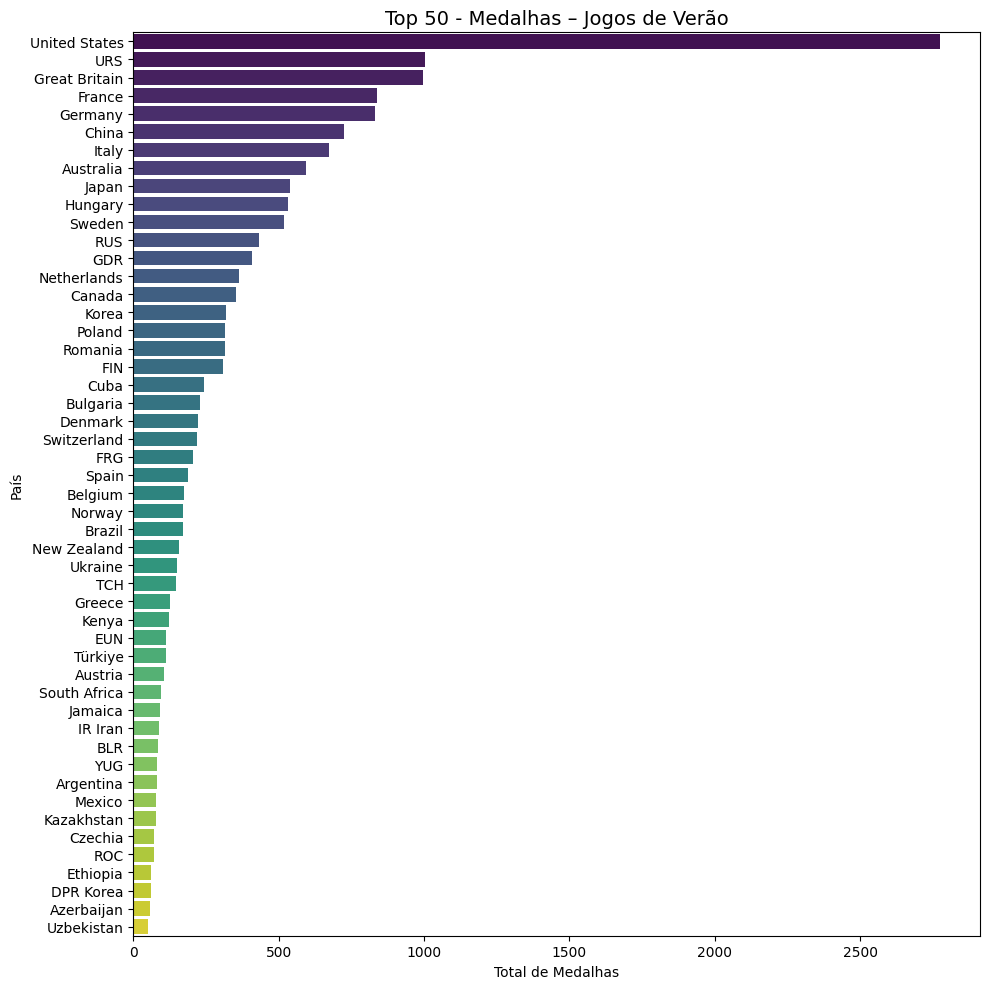


Tabela: Medalhas – Jogos de Inverno (Top 50)


medal,País,Ouro,Prata,Bronze,Total
127,Norway,147,134,123,404
188,United States,113,119,95,327
68,Germany,112,104,70,286
8,Austria,71,88,91,250
26,Canada,77,72,76,225


/tmp/ipykernel_902/4019088659.py:72: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Total', y='País', data=df, palette='viridis')


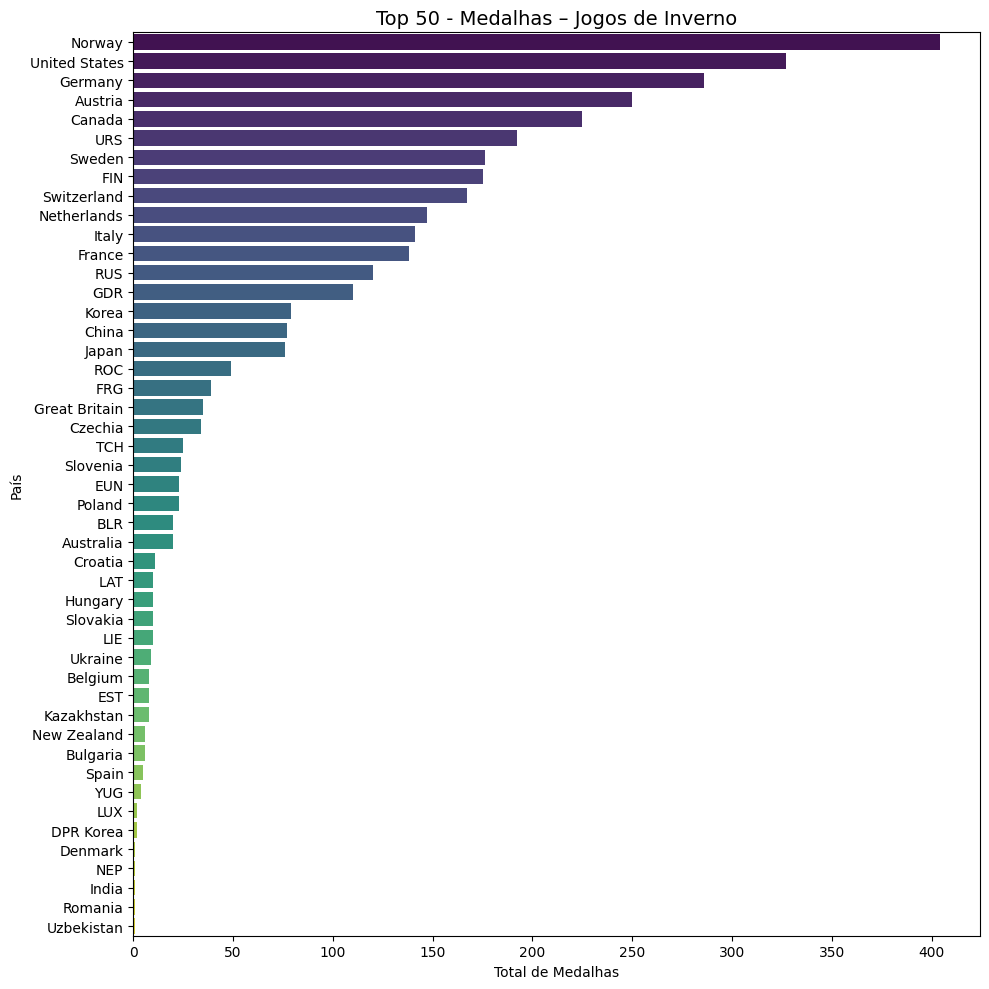


Tabela: Medalhas – Total Geral (Top 50)


,País,Ouro,Prata,Bronze,Total
152,United States,1219.0,1003.0,879.0,3101.0
150,URS,471.0,373.0,353.0,1197.0
55,Germany,364.0,384.0,369.0,1117.0
52,Great Britain,320.0,350.0,360.0,1030.0
49,France,288.0,326.0,362.0,976.0


/tmp/ipykernel_902/4019088659.py:72: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Total', y='País', data=df, palette='viridis')


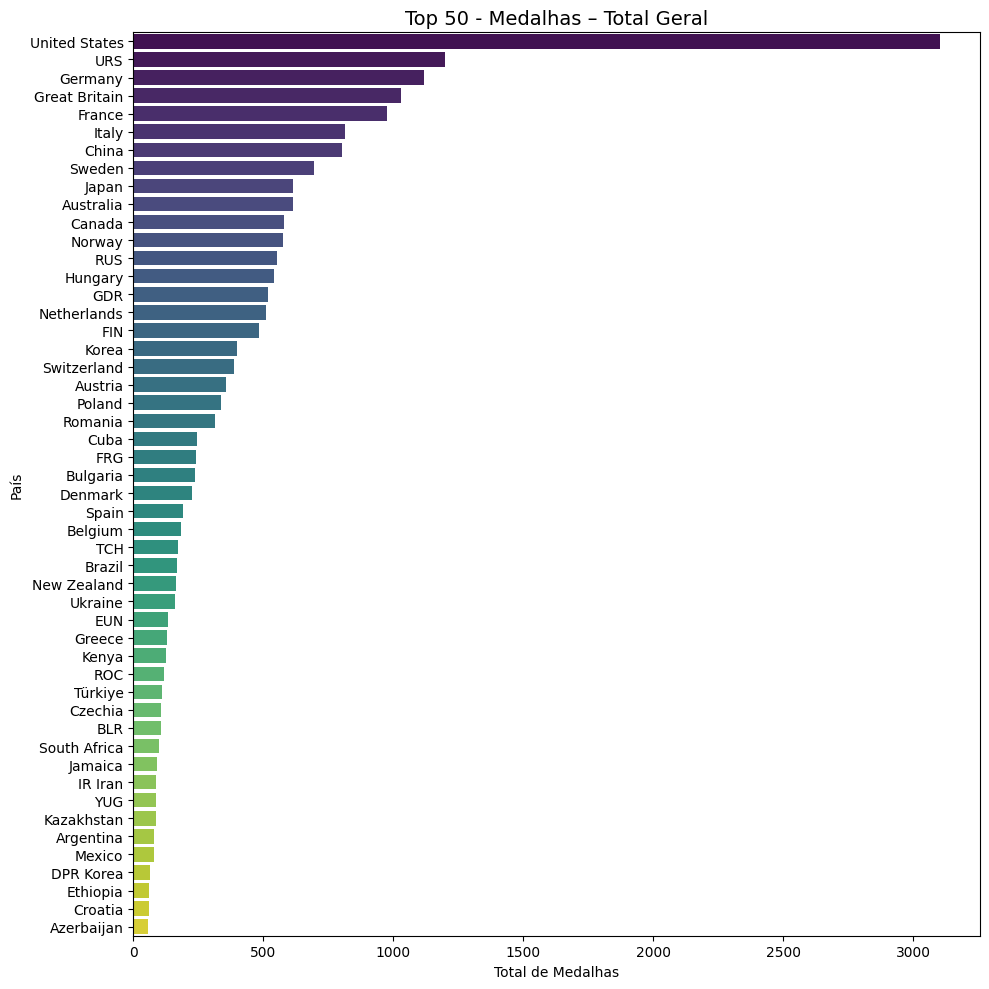

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Carregamento dos dados
medalhas_2024 = pd.read_csv('medals_total.csv')
resultados_historicos = pd.read_csv('world_olympedia_olympics_athlete_event_result.csv', low_memory=False)

# 2. Processamento do Histórico (1896-2022)
historico_medalhas = resultados_historicos[resultados_historicos['medal'].notna()].copy()

# Definindo as temporadas
historico_medalhas['temporada'] = historico_medalhas['edition'].apply(lambda x: 'Inverno' if 'Winter' in x else 'Verão')

# Evitar contagem duplicada em esportes coletivos
medalhas_unicas_hist = historico_medalhas.drop_duplicates(subset=['edition', 'country_noc', 'result_id', 'medal'])

# Criar resumo de medalhas por país e temporada
pivot_historico = medalhas_unicas_hist.groupby(['country_noc', 'temporada', 'medal']).size().unstack(fill_value=0).reset_index()
pivot_historico.rename(columns={'Gold': 'Ouro', 'Silver': 'Prata', 'Bronze': 'Bronze'}, inplace=True)

# Garantir que todas as colunas de medalhas existam
for col in ['Ouro', 'Prata', 'Bronze']:
    if col not in pivot_historico.columns:
        pivot_historico[col] = 0

# 3. Preparação dos dados de 2024 (Jogos de Verão)
medalhas_2024_limpo = medalhas_2024[['country_code', 'country', 'Gold Medal', 'Silver Medal', 'Bronze Medal']].copy()
medalhas_2024_limpo.columns = ['country_noc', 'País', 'Ouro', 'Prata', 'Bronze']

# 4. JOGOS DE VERÃO (Histórico + 2024)
verao_hist = pivot_historico[pivot_historico['temporada'] == 'Verão'].drop(columns='temporada').copy()
verao_consolidado = pd.merge(verao_hist, medalhas_2024_limpo, on='country_noc', how='outer', suffixes=('_hist', '_2024')).fillna(0)

for m in ['Ouro', 'Prata', 'Bronze']:
    verao_consolidado[m] = verao_consolidado[f'{m}_hist'] + verao_consolidado[f'{m}_2024']

verao_consolidado['Total'] = verao_consolidado['Ouro'] + verao_consolidado['Prata'] + verao_consolidado['Bronze']
verao_consolidado['País'] = verao_consolidado['País'].where(verao_consolidado['País'] != 0, verao_consolidado['country_noc'])

# Tabela Final Verão - Top 50
tabela_verao_top50 = verao_consolidado[['País', 'Ouro', 'Prata', 'Bronze', 'Total']].sort_values('Total', ascending=False).head(50)

# 5. JOGOS DE INVERNO
inverno_hist = pivot_historico[pivot_historico['temporada'] == 'Inverno'].drop(columns='temporada').copy()
inverno_hist['Total'] = inverno_hist['Ouro'] + inverno_hist['Prata'] + inverno_hist['Bronze']

# Mapear nomes de países para os códigos NOC conhecidos
mapa_nomes = medalhas_2024.set_index('country_code')['country'].to_dict()
inverno_hist['País'] = inverno_hist['country_noc'].map(mapa_nomes).fillna(inverno_hist['country_noc'])

# Tabela Final Inverno - Top 50
tabela_inverno_top50 = inverno_hist[['País', 'Ouro', 'Prata', 'Bronze', 'Total']].sort_values('Total', ascending=False).head(50)

# 6. TOTAL GERAL (Verão + Inverno + 2024)
geral_hist = medalhas_unicas_hist.groupby(['country_noc', 'medal']).size().unstack(fill_value=0).reset_index()
geral_hist.rename(columns={'Gold': 'Ouro', 'Silver': 'Prata', 'Bronze': 'Bronze'}, inplace=True)

geral_consolidado = pd.merge(geral_hist, medalhas_2024_limpo, on='country_noc', how='outer', suffixes=('_hist', '_2024')).fillna(0)
for m in ['Ouro', 'Prata', 'Bronze']:
    geral_consolidado[m] = geral_consolidado[f'{m}_hist'] + geral_consolidado[f'{m}_2024']

geral_consolidado['Total'] = geral_consolidado['Ouro'] + geral_consolidado['Prata'] + geral_consolidado['Bronze']
geral_consolidado['País'] = geral_consolidado['País'].where(geral_consolidado['País'] != 0, geral_consolidado['country_noc'])

# Tabela Final Geral - Top 50
tabela_geral_top50 = geral_consolidado[['País', 'Ouro', 'Prata', 'Bronze', 'Total']].sort_values('Total', ascending=False).head(50)

# 7. Geração de Gráficos e Exportação
def gerar_grafico(df, titulo):
    plt.figure(figsize=(10, 10))
    sns.barplot(x='Total', y='País', data=df, palette='viridis')
    plt.title(f'Top 50 - {titulo}', fontsize=14)
    plt.xlabel('Total de Medalhas')
    plt.ylabel('País')
    plt.tight_layout()
    plt.show()

# Exportar para CSV
tabela_verao_top50.to_csv('medalhas_verao_top50.csv', index=False)
tabela_inverno_top50.to_csv('medalhas_inverno_top50.csv', index=False)
tabela_geral_top50.to_csv('medalhas_geral_top50.csv', index=False)

# Exibir Tabelas e Gráficos
print("Tabela: Medalhas – Jogos de Verão (Top 50)")
display(tabela_verao_top50.head())
gerar_grafico(tabela_verao_top50, 'Medalhas – Jogos de Verão')

print("\nTabela: Medalhas – Jogos de Inverno (Top 50)")
display(tabela_inverno_top50.head())
gerar_grafico(tabela_inverno_top50, 'Medalhas – Jogos de Inverno')

print("\nTabela: Medalhas – Total Geral (Top 50)")
display(tabela_geral_top50.head())
gerar_grafico(tabela_geral_top50, 'Medalhas – Total Geral')